<a href="https://colab.research.google.com/github/Josiah-Kunz/MGN-Public/blob/colab-examples/examples/colab/ml_mwe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Get FEniCS and dolfin

In [5]:
%%capture
"""
Get fenics and dolfin
"""

try:
    import google.colab  # noqa: F401
except ImportError:
    import ufl_legacy
    import fenics
else:
    try:
        import ufl_legacy
        import fenics
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
        import ufl_legacy
        import fenics

# Install + Import Other Packages

In [6]:
%%capture
!apt-get install -y libglu1-mesa -q
!pip install gmsh meshio pint torch torch-geometric scikit-learn -q
!pip install git+https://github.com/Josiah-Kunz/MGN-Public.git -q

import os
from sklearn.ensemble import GradientBoostingRegressor
from main_package import MLObject

# Acquire FEM Results

In [7]:
!wget "https://raw.githubusercontent.com/Josiah-Kunz/MGN-Public/refs/heads/colab-examples/examples/cantilever/results/cantilever_fem_results.csv" -O "cantilever_fem_results.csv" -q

# Train Machine Learning Model and Compare

In [8]:
def main():

    # Construct the machine learning object
    ml = MLObject(
        data="cantilever_fem_results.csv",
        features=["x (m)", "y (m)"],
        objectives=["von_mises (GPa)"],
        name="Cantilever Analysis"
    )

    # Train + test machine learning
    # Note that the default is sklearn linear regression model,
    #   which isn't great for cantilevers
    ml.train(model=GradientBoostingRegressor())
    ml.evaluate_on_unseen_data()
    ml.plot_predictions()

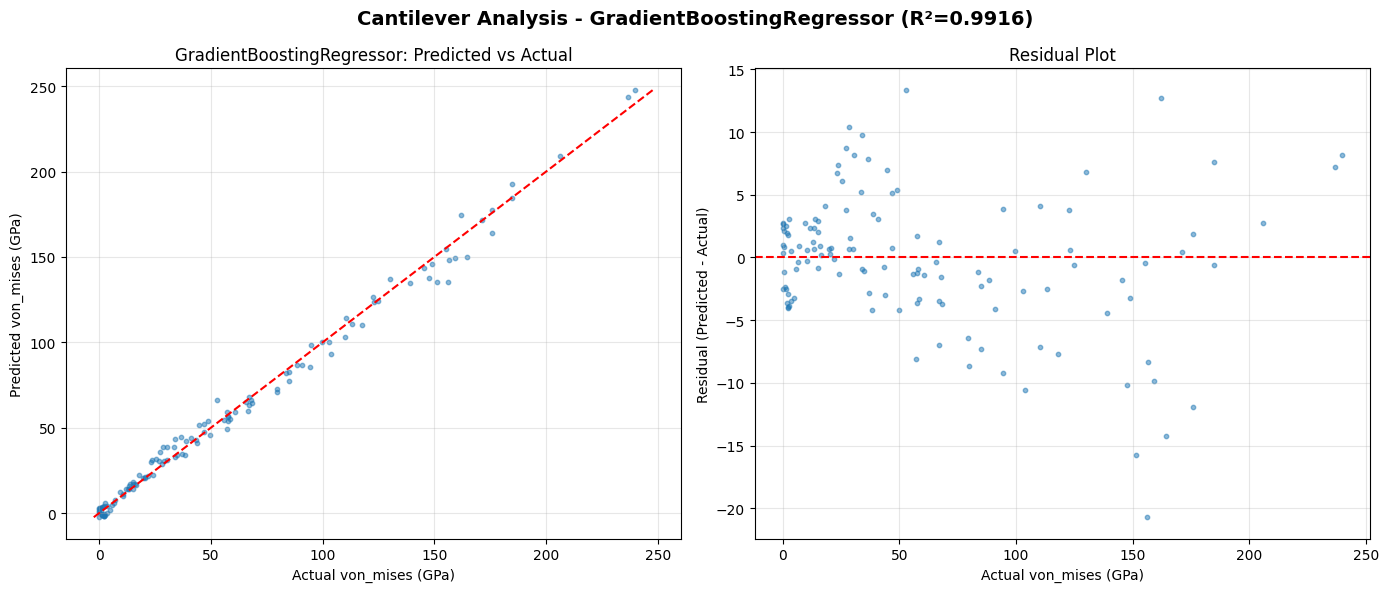

In [9]:
if __name__ == "__main__":
    main()